# Projeto Big Data — Crimes em Chicago
**Pipeline:** Ingestão → ETL → EDA → Machine Learning com Apache Spark  
**Target:** `Arrest` (Classificação Binária — predizer se o crime resultará em prisão)

---
## Parte 1 — Ambiente e Ingestão (CSV → Parquet)

In [1]:
# Importa SparkSession: porta de entrada do Spark, cria o contexto e a sessão
from pyspark.sql import SparkSession
# col=referência a coluna; to_timestamp=converte string→datetime; hour/dayofweek/month=extraem partes da data
from pyspark.sql.functions import col, to_timestamp, hour, dayofweek, month
# Tipos usados em cast: IntegerType=inteiro 32-bit, DoubleType=float 64-bit
from pyspark.sql.types import IntegerType, DoubleType
# StringIndexer: string categórica → índice numérico ordenado por frequência
# OneHotEncoder: índice → vetor binário esparso (remove a última categoria para evitar multicolinearidade)
# VectorAssembler: concatena múltiplas colunas num único vetor de features
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
# Os 3 algoritmos de classificação usados no projeto
from pyspark.ml.classification import (
    LogisticRegression,                    # modelo linear — baseline
    DecisionTreeClassifier,                # árvore de decisão
    MultilayerPerceptronClassifier         # rede neural MLP
)
# Pipeline: encadeia estágios de transformação + modelo num objeto treinável único
from pyspark.ml import Pipeline
# Avaliador multi-classe: calcula accuracy, precision, recall e F1-score
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [2]:
# Cria ou recupera a SparkSession existente (singleton por JVM)
spark = SparkSession.builder \
    .appName("CrimesChicago_BigData") \        # nome exibido na Spark UI
    .master("spark://spark-master:7077") \     # endereço do master no cluster Docker
    .config("spark.driver.host", "jupyter") \         # host do driver = container jupyter
    .config("spark.driver.bindAddress", "0.0.0.0") \  # aceita conexões em todas as interfaces
    .config("spark.driver.memory", "2g") \            # RAM do processo driver (Python + JVM)
    .config("spark.executor.memory", "2g") \          # RAM de cada executor nos workers
    .config("spark.sql.shuffle.partitions", "50") \   # reduz partições após shuffles (padrão=200)
    .getOrCreate()                                      # retorna sessão existente ou cria uma nova

# Suprime logs INFO/DEBUG; mantém apenas WARN e ERROR
spark.sparkContext.setLogLevel("WARN")
# Confirma a versão do Spark e o master ao qual o driver está conectado
print(f"Spark version: {spark.version}")
print(f"Master: {spark.sparkContext.master}")

Spark version: 3.5.0
Master: spark://spark-master:7077


### 1.1 Leitura dos CSVs do Data Lake Local

In [3]:
# Lê todos os CSVs da pasta archive/ de uma só vez — Spark os trata como um único DataFrame
df_raw = spark.read.csv(
    "/home/jovyan/work/archive/",   # pasta mapeada pelo volume Docker (../archive)
    header=True,        # primeira linha de cada CSV é o cabeçalho
    inferSchema=True    # Spark infere o tipo de cada coluna (int, double, string...)
)

# Conta o total de linhas — operação wide que varre todos os arquivos
print(f"Total de linhas: {df_raw.count():,}")
# Conta o número de colunas do schema inferido
print(f"Total de colunas: {len(df_raw.columns)}")
# Imprime o schema: nomes, tipos e flag nullable de cada coluna
df_raw.printSchema()

Total de linhas: 7,941,286
Total de colunas: 23
root
 |-- _c0: integer (nullable = true)
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: string (nullable = true)
 |-- Domestic: string (nullable = true)
 |-- Beat: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Ward: string (nullable = true)
 |-- Community Area: string (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: string (nullable = true)
 |-- Y Coordinate: string (nullable = true)
 |-- Year: string (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Location: string (nullable = true)



In [4]:
# Exibe as 5 primeiras linhas do DataFrame para inspeção visual dos dados brutos
df_raw.show(5)

+----+----+-----------+--------------------+-------------------+----+------------+-------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
| _c0|  ID|Case Number|                Date|              Block|IUCR|Primary Type|        Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|    Latitude|    Longitude|            Location|
+----+----+-----------+--------------------+-------------------+----+------------+-------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
| 388|4785|   HP610824|10/07/2008 12:39:...|    000XX E 75TH ST|0110|    HOMICIDE|FIRST DEGREE MURDER|               ALLEY|  True|   False| 323|     3.

### 1.2 Conversão para Parquet (Otimização de Storage)

In [5]:
# Caminho de destino dentro do volume Docker (mapeado para ../data_parquet no host)
PARQUET_PATH = "/home/jovyan/work/data_parquet/crimes_raw"

# Converte os CSVs para Parquet com compressão Snappy (padrão do Spark)
# mode='overwrite' permite re-executar a célula sem erro de diretório existente
# Parquet é colunar: leituras futuras carregam só as colunas necessárias (~70% menor que CSV)
df_raw.write.mode("overwrite").parquet(PARQUET_PATH)
print(f"Parquet salvo em: {PARQUET_PATH}")

Parquet salvo em: /home/jovyan/work/data_parquet/crimes_raw


---
## Parte 2 — EDA e Pré-processamento (ETL)

### 2.1 Leitura Otimizada a partir do Parquet

In [6]:
# Lê o Parquet gerado na Parte 1 — muito mais rápido que reler os CSVs
df = spark.read.parquet(PARQUET_PATH)
# Confirma que o schema foi preservado corretamente após a conversão
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: string (nullable = true)
 |-- Domestic: string (nullable = true)
 |-- Beat: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Ward: string (nullable = true)
 |-- Community Area: string (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: string (nullable = true)
 |-- Y Coordinate: string (nullable = true)
 |-- Year: string (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Location: string (nullable = true)



### 2.2 Análise de Qualidade dos Dados

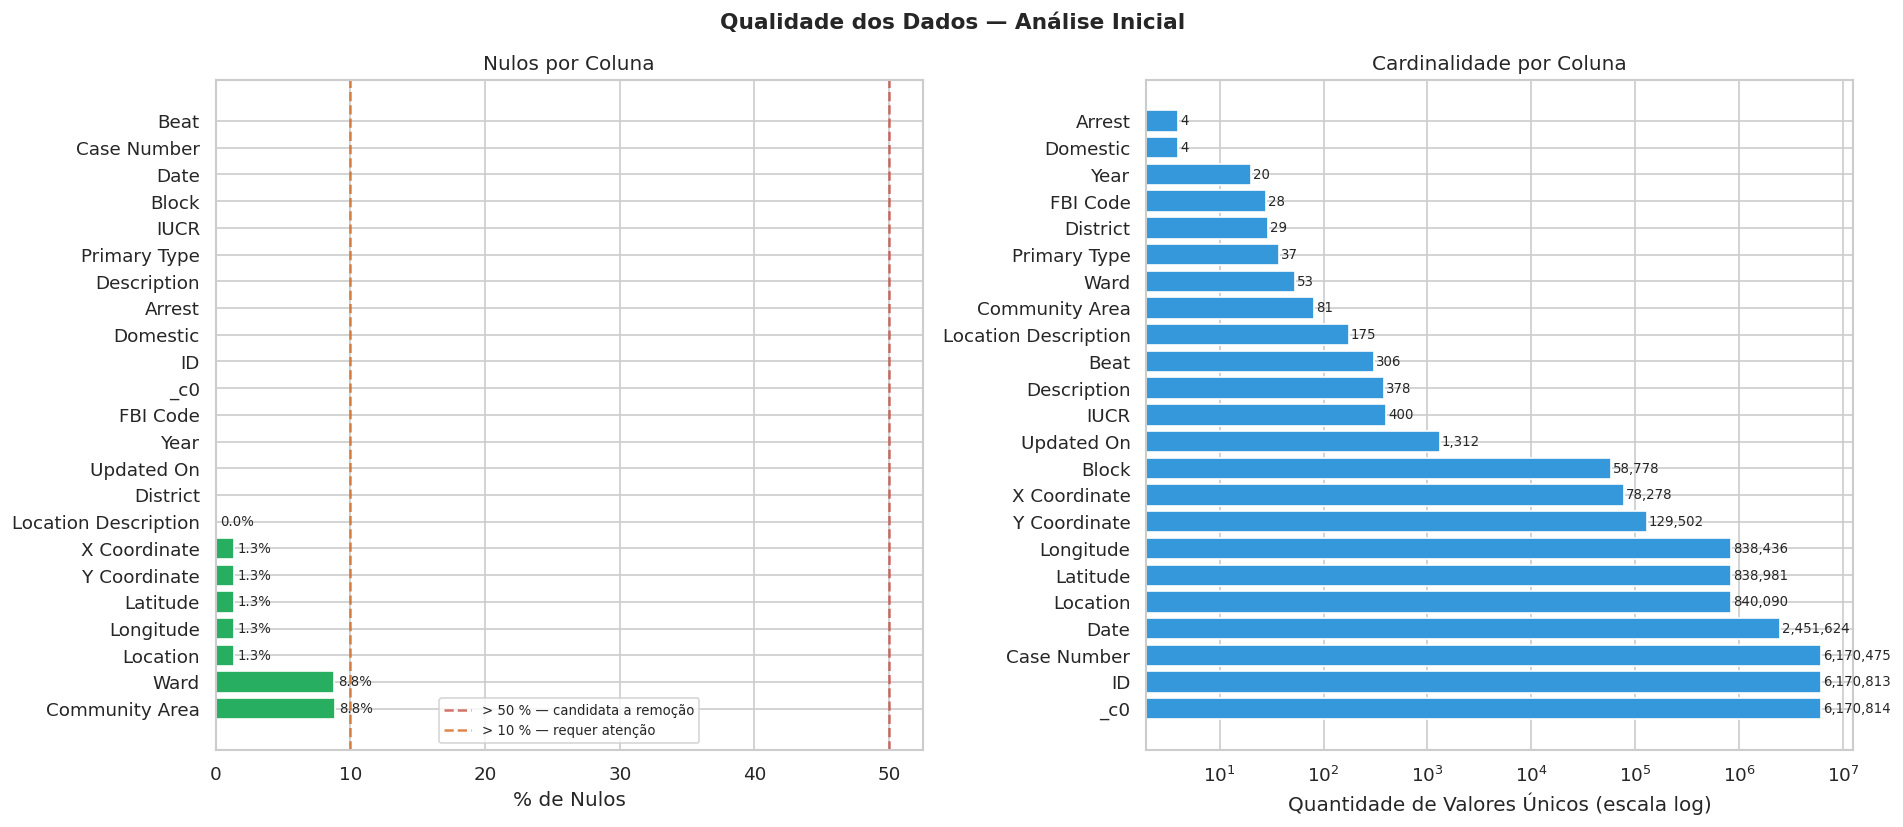

Total de linhas no parquet: 7,941,286


In [7]:
# Importações de visualização e manipulação de dados
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Tema visual padrão para todos os gráficos do projeto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
# Diretório onde todos os gráficos serão salvos (mapeado para ../data_parquet no host)
SAVE_DIR = "/home/jovyan/work/data_parquet/"

# Funções adicionais do Spark SQL necessárias para contagens
from pyspark.sql.functions import col, count, when

# Total de linhas no Parquet bruto — denominador para calcular % de nulos
total_raw = df.count()

# Cria uma lista de expressões: para cada coluna, conta quantos valores são nulos
null_expr = [count(when(col(c).isNull(), c)).alias(c) for c in df.columns]
# Executa todas as contagens de nulos em uma única passagem pelo dataset
null_row  = df.agg(*null_expr).collect()[0]

# Converte o resultado para um DataFrame pandas com % de nulos por coluna
null_pd = pd.DataFrame([
    {"Coluna": c, "Nulos (%)": round(null_row[c] / total_raw * 100, 2)}
    for c in df.columns
]).sort_values("Nulos (%)", ascending=False)

# Para cada coluna conta valores únicos (cardinalidade) — útil para detectar categorias
uniq_pd = pd.DataFrame([
    {"Coluna": c, "Valores únicos": df.select(c).distinct().count()}
    for c in df.columns
]).sort_values("Valores únicos", ascending=False)

# Dois gráficos lado a lado: nulos à esquerda, cardinalidade à direita
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Cores semafóricas: vermelho >50%, laranja >10%, verde ok
colors_null = ["#e74c3c" if p > 50 else "#e67e22" if p > 10 else "#27ae60" for p in null_pd["Nulos (%)"]]
# Gráfico horizontal de barras: % de nulos por coluna
axes[0].barh(null_pd["Coluna"], null_pd["Nulos (%)"], color=colors_null, edgecolor="white")
axes[0].set_xlabel("% de Nulos")
axes[0].set_title("Nulos por Coluna")
# Linhas de referência em 50% e 10% para facilitar a leitura
axes[0].axvline(x=50, color="#c0392b", linestyle="--", alpha=0.7, label="> 50 % — candidata a remoção")
axes[0].axvline(x=10, color="#d35400", linestyle="--", alpha=0.7, label="> 10 % — requer atenção")
axes[0].legend(fontsize=8)
# Anota o valor exato de % em cada barra
for bar, val in zip(axes[0].patches, null_pd["Nulos (%)"]):
    if val > 0:
        axes[0].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=8)

# Gráfico de cardinalidade em escala logarítmica (valores variam de 2 a milhões)
axes[1].barh(uniq_pd["Coluna"], uniq_pd["Valores únicos"], color="#3498db", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_xlabel("Quantidade de Valores Únicos (escala log)")
axes[1].set_title("Cardinalidade por Coluna")
for bar, val in zip(axes[1].patches, uniq_pd["Valores únicos"]):
    axes[1].text(val * 1.05, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=8)

fig.suptitle("Qualidade dos Dados — Análise Inicial", fontsize=13, fontweight="bold")
plt.tight_layout()
# Salva o gráfico em PNG para uso nos slides
plt.savefig(SAVE_DIR + "data_quality.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Total de linhas no parquet: {total_raw:,}")

### 2.3 Limpeza dos Dados

In [8]:
# Remove linhas onde qualquer uma das colunas críticas é nula
# Essas colunas são imprescindíveis para o modelo: sem elas não há como prever
df = df.dropna(subset=["Date", "Primary Type", "Location Description",
                        "Arrest", "Latitude", "Longitude", "District", "Beat"])

# Remove registros com coordenadas (0.0, 0.0) — indica ausência de geolocalização válida
# Chicago fica em ~(41.8, -87.6), então (0,0) é claramente inválido
df = df.filter((col("Latitude") != 0.0) & (col("Longitude") != 0.0))

# Remove o tipo NARCOTICS: 99.21% dos crimes de narcóticos resultam em prisão
# Manter esse tipo cria um atalho trivial que distorce feature importance e métricas
# Qualquer modelo que identificasse esse tipo acertaria automaticamente ~8% do dataset
df = df.filter(col("Primary Type") != "NARCOTICS")

# Confirma o total de linhas após a limpeza completa
print(f"Linhas após limpeza e remoção de NARCOTICS: {df.count():,}")

Linhas após limpeza e remoção de NARCOTICS: 6,962,654


### 2.4 Feature Engineering
Timestamp bruto decomposto em `Hour`, `DayOfWeek` e `Month` para o pipeline de ML.

In [9]:
# Converte a string de data (ex: '01/15/2010 08:30:00 PM') para tipo timestamp do Spark
df = df.withColumn("Date_ts", to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a"))

# Extrai a hora do dia (0–23) — captura padrões de criminalidade por período
df = df.withColumn("Hour",      hour("Date_ts"))
# Extrai o dia da semana (1=domingo...7=sábado no Spark) — detecta padrões semanais
df = df.withColumn("DayOfWeek", dayofweek("Date_ts"))
# Extrai o mês (1–12) — captura sazonalidade anual dos crimes
df = df.withColumn("Month",     month("Date_ts"))

# Converte 'Arrest' de string 'True'/'False' para inteiro 0/1 (necessário para MLlib)
df = df.withColumn("Arrest_label", (col("Arrest") == "True").cast(IntegerType()))

# Converte 'Domestic' de string para inteiro 0/1
df = df.withColumn("Domestic_int", (col("Domestic") == "True").cast(IntegerType()))

# Garante que colunas numéricas geográficas e administrativas estejam no tipo correto
df = df.withColumn("District",       col("District").cast(IntegerType()))
df = df.withColumn("Beat",           col("Beat").cast(IntegerType()))
df = df.withColumn("Community Area", col("Community Area").cast(IntegerType()))

# Garante que lat/lon sejam double (podem ter sido inferidos como string em alguns CSVs)
df = df.withColumn("Latitude",  col("Latitude").cast(DoubleType()))
df = df.withColumn("Longitude", col("Longitude").cast(DoubleType()))

In [10]:
# Lista de colunas que o modelo usará como entrada (features)
# Inclui: tipo de crime (categórica), localização (categórica), hora/dia/mês (temporais),
# distrito/beat/área (geoadministrativas), doméstico (flag binária), lat/lon (geoespaciais)
FEATURE_COLS = [
    "Primary Type", "Location Description",
    "Hour", "DayOfWeek", "Month",
    "District", "Beat", "Community Area",
    "Domestic_int", "Latitude", "Longitude"
]
# Coluna alvo: 1 = houve prisão, 0 = não houve prisão
TARGET_COL = "Arrest_label"

# Seleciona apenas as colunas relevantes e remove linhas com qualquer nulo restante
# O dropna() final garante que o pipeline de ML não receba valores nulos
df = df.select(FEATURE_COLS + [TARGET_COL]).dropna()
print(f"Dataset final: {df.count():,} linhas | {len(df.columns)} colunas")
df.show(5)

Dataset final: 6,349,252 linhas | 12 colunas
+------------+--------------------+----+---------+-----+--------+----+--------------+------------+------------+-------------+------------+
|Primary Type|Location Description|Hour|DayOfWeek|Month|District|Beat|Community Area|Domestic_int|    Latitude|    Longitude|Arrest_label|
+------------+--------------------+----+---------+-----+--------+----+--------------+------------+------------+-------------+------------+
|    HOMICIDE|               ALLEY|  12|        3|   10|       3| 323|            69|           0|41.758275857|-87.622451031|           1|
|    HOMICIDE|              STREET|   3|        5|   10|      15|1533|            25|           0| 41.87025207|-87.746069362|           1|
|    HOMICIDE|       PARK PROPERTY|   8|        5|   10|       8| 831|            66|           0|41.770990476|-87.698901469|           0|
|    HOMICIDE|          RESTAURANT|   2|        6|   10|      15|1524|            25|           0|41.894916924|-87.757358

### 2.5 Análise Exploratória com Spark SQL

In [11]:
# Registra o DataFrame como uma tabela temporária no catálogo do Spark
# A partir daqui é possível consultar os dados com SQL puro usando spark.sql()
df.createOrReplaceTempView("crimes")

In [12]:
# Consulta SQL: top 10 tipos de crime por volume e suas taxas de prisão
# SUM(Arrest_label)/COUNT(*) = média aritmética do campo binário = taxa de prisão
spark.sql("""
    SELECT `Primary Type`,
           COUNT(*)                                          AS total_crimes,
           SUM(Arrest_label)                                 AS total_arrests,
           ROUND(SUM(Arrest_label) / COUNT(*) * 100, 2)     AS arrest_rate_pct
    FROM crimes
    GROUP BY `Primary Type`
    ORDER BY total_crimes DESC
    LIMIT 10
""").show(truncate=False)

+-------------------+------------+-------------+---------------+
|Primary Type       |total_crimes|total_arrests|arrest_rate_pct|
+-------------------+------------+-------------+---------------+
|THEFT              |1476390     |172606       |11.69          |
|BATTERY            |1298245     |298521       |22.99          |
|CRIMINAL DAMAGE    |835316      |58415        |6.99           |
|OTHER OFFENSE      |440885      |74728        |16.95          |
|ASSAULT            |432905      |102917       |23.77          |
|BURGLARY           |430571      |24545        |5.7            |
|MOTOR VEHICLE THEFT|328768      |28035        |8.53           |
|ROBBERY            |271450      |26855        |9.89           |
|DECEPTIVE PRACTICE |247715      |45350        |18.31          |
|CRIMINAL TRESPASS  |207725      |151451       |72.91          |
+-------------------+------------+-------------+---------------+



In [13]:
# Analisa como a taxa de prisão varia ao longo das 24 horas do dia
# AVG(Arrest_label) * 100 é equivalente a SUM/COUNT mas mais conciso
spark.sql("""
    SELECT Hour,
           COUNT(*)                             AS total_crimes,
           ROUND(AVG(Arrest_label) * 100, 2)   AS arrest_rate_pct
    FROM crimes
    GROUP BY Hour
    ORDER BY Hour
""").show(24)

+----+------------+---------------+
|Hour|total_crimes|arrest_rate_pct|
+----+------------+---------------+
|   0|      374288|          14.65|
|   1|      212248|          21.73|
|   2|      181487|          21.82|
|   3|      147704|           20.8|
|   4|      111032|          19.25|
|   5|       92738|          16.74|
|   6|      108296|          16.81|
|   7|      157660|          15.67|
|   8|      229915|          15.23|
|   9|      285913|          14.37|
|  10|      265679|           18.3|
|  11|      263751|          21.53|
|  12|      348401|          17.53|
|  13|      287646|          20.32|
|  14|      313692|          19.24|
|  15|      338725|          18.95|
|  16|      320442|          19.82|
|  17|      330120|          19.18|
|  18|      346102|          19.58|
|  19|      340844|          22.18|
|  20|      341713|          22.66|
|  21|      335132|          22.06|
|  22|      335840|          20.74|
|  23|      279884|          21.59|
+----+------------+---------

In [14]:
# Analisa taxa de prisão por distrito policial
# HAVING COUNT(*) > 1000 remove distritos com poucos registros (estatisticamente irrelevantes)
# ORDER BY ASC: distritos com menor taxa de prisão primeiro (áreas de maior risco)
spark.sql("""
    SELECT District,
           COUNT(*)                                         AS total_crimes,
           ROUND(SUM(Arrest_label) / COUNT(*) * 100, 2)   AS arrest_rate_pct
    FROM crimes
    WHERE District IS NOT NULL
    GROUP BY District
    HAVING COUNT(*) > 1000
    ORDER BY arrest_rate_pct ASC
    LIMIT 10
""").show()

+--------+------------+---------------+
|District|total_crimes|arrest_rate_pct|
+--------+------------+---------------+
|      22|      216955|          14.81|
|      16|      224927|          14.97|
|       4|      373026|          15.92|
|      14|      261085|          16.93|
|      24|      195166|          17.63|
|      19|      296889|          17.65|
|       5|      283438|          17.77|
|       8|      458707|          18.12|
|      20|      112862|           18.6|
|       7|      376477|          18.66|
+--------+------------+---------------+



### 2.6 Análise de Desbalanceamento da Classe `Arrest`

In [15]:
# Exibe a distribuição bruta da classe alvo (0 = sem prisão, 1 = com prisão)
print("Distribuição da classe Arrest:")
df.groupBy(TARGET_COL).count().orderBy(TARGET_COL).show()

# Contagem separada de cada classe — necessária para calcular a fração de undersampling
count_arrest    = df.filter(col(TARGET_COL) == 1).count()
count_no_arrest = df.filter(col(TARGET_COL) == 0).count()
total           = count_arrest + count_no_arrest

# Exibe o desbalanceamento em termos percentuais e razão
print(f"Arrests (1):    {count_arrest:,}  ({count_arrest/total*100:.1f}%)")
print(f"No Arrest (0):  {count_no_arrest:,}  ({count_no_arrest/total*100:.1f}%)")
print(f"Razão de desbalanceamento: 1:{count_no_arrest//count_arrest}")

Distribuição da classe Arrest:
+------------+-------+
|Arrest_label|  count|
+------------+-------+
|           0|5120978|
|           1|1228274|
+------------+-------+

Arrests (1):    1,228,274  (19.3%)
No Arrest (0):  5,120,978  (80.7%)
Razão de desbalanceamento: 1:4


### 2.7 Balanceamento — Undersampling da Classe Majoritária

In [16]:
# Calcula a fração necessária para equiparar a classe majoritária (0) à minoritária (1)
# fraction = qtd_minoritária / qtd_majoritária → amostrar exatamente o mesmo número
fraction = count_arrest / count_no_arrest

# Amostra aleatória da classe majoritária (sem prisão) com seed fixo para reprodutibilidade
df_majority = df.filter(col(TARGET_COL) == 0).sample(fraction=fraction, seed=42)
# Mantém todos os registros da classe minoritária (com prisão) sem alteração
df_minority = df.filter(col(TARGET_COL) == 1)

# Une os dois subsets: resultado deve ter ~50% de cada classe
df_balanced = df_majority.union(df_minority)

# Confirma o total e a nova distribuição 50/50
print(f"Dataset balanceado: {df_balanced.count():,} linhas")
df_balanced.groupBy(TARGET_COL).count().orderBy(TARGET_COL).show()

Dataset balanceado: 2,457,954 linhas
+------------+-------+
|Arrest_label|  count|
+------------+-------+
|           0|1229680|
|           1|1228274|
+------------+-------+



In [17]:
# Persiste o dataset balanceado em Parquet para que a Parte 3 não precise refazer ETL
# Isso também protege contra perda de dados se o SparkContext morrer durante o ML
BALANCED_PATH = "/home/jovyan/work/data_parquet/crimes_balanced"
df_balanced.write.mode("overwrite").parquet(BALANCED_PATH)
print(f"Checkpoint salvo em: {BALANCED_PATH}")

Checkpoint salvo em: /home/jovyan/work/data_parquet/crimes_balanced


---
## Parte 3 — Machine Learning (Pipeline + Avaliação)

### 3.1 Configuração dos Estágios de Feature Engineering

In [18]:
# Colunas categóricas que precisam de encoding antes de entrar no modelo
CAT_COLS     = ["Primary Type", "Location Description"]
# Nomes das colunas de saída do StringIndexer (sufixo _idx)
INDEXED_COLS = [c + "_idx" for c in CAT_COLS]
# Nomes das colunas de saída do OneHotEncoder (sufixo _enc)
ENCODED_COLS = [c + "_enc" for c in CAT_COLS]

# Colunas numéricas: passam direto para o VectorAssembler sem transformação
NUMERIC_COLS = [
    "Hour", "DayOfWeek", "Month",
    "District", "Beat", "Community Area",
    "Domestic_int", "Latitude", "Longitude"
]

# Cria um StringIndexer para cada coluna categórica
# handleInvalid='skip': remove linhas com categorias não vistas no treino (evita erro no teste)
indexers = [
    StringIndexer(inputCol=c, outputCol=idx, handleInvalid="skip")
    for c, idx in zip(CAT_COLS, INDEXED_COLS)
]

# OneHotEncoder: transforma os índices em vetores esparsos binários
# inputCols/outputCols são listas: processa ambas as colunas em uma única etapa
encoder = OneHotEncoder(
    inputCols=INDEXED_COLS,
    outputCols=ENCODED_COLS
)

# VectorAssembler: combina vetores OHE + colunas numéricas em um único vetor 'features'
assembler = VectorAssembler(
    inputCols=ENCODED_COLS + NUMERIC_COLS,
    outputCol="features"
)

# Estágios base de pré-processamento compartilhados pelos 3 modelos
BASE_STAGES = indexers + [encoder, assembler]

### 3.2 Divisão Treino / Teste e Cálculo do Tamanho do Vetor de Features

In [19]:
# Divide o dataset balanceado: 80% treino, 20% teste, seed fixo para reprodutibilidade
train_data, test_data = df_balanced.randomSplit([0.8, 0.2], seed=42)
print(f"Treino: {train_data.count():,} | Teste: {test_data.count():,}")

# Aplica o pipeline de pré-processamento em 1 linha do treino para descobrir o INPUT_SIZE
# O tamanho do vetor de features depende do número de categorias únicas nos dados
pre_pipeline  = Pipeline(stages=BASE_STAGES)
pre_model     = pre_pipeline.fit(train_data)       # aprende os vocabulários das colunas categóricas
sample_vector = pre_model.transform(train_data.limit(1))  # transforma 1 linha para inspecionar o vetor
INPUT_SIZE    = len(sample_vector.select("features").first()[0])  # comprimento do vetor de features

print(f"Tamanho do vetor de features: {INPUT_SIZE}")

Treino: 1,966,338 | Teste: 491,616
Tamanho do vetor de features: 203


### 3.3 Função Auxiliar de Avaliação

In [20]:
# Função auxiliar que calcula as 4 métricas de avaliação para qualquer modelo
def evaluate_model(predictions, label_col=TARGET_COL):
    # Cria o avaliador apontando para a coluna alvo correta
    evaluator = MulticlassClassificationEvaluator(labelCol=label_col)
    metrics = {}
    # Itera pelas 4 métricas, reutilizando o mesmo objeto avaliador
    for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
        evaluator.setMetricName(metric)          # altera qual métrica será calculada
        metrics[metric] = round(evaluator.evaluate(predictions), 4)
    return metrics

### 3.4 Modelo 1 — Logistic Regression (Baseline)

In [21]:
# Configura a Regressão Logística com 10 iterações — modelo linear, serve como baseline
# maxIter=10 é suficiente para convergência com dados bem normalizados
lr = LogisticRegression(
    labelCol=TARGET_COL,
    featuresCol="features",
    maxIter=10
)

# Monta o pipeline completo: pré-processamento + LR
pipeline_lr = Pipeline(stages=BASE_STAGES + [lr])
# Treina: o pipeline aprende vocabulários (StringIndexer) e pesos do modelo
model_lr    = pipeline_lr.fit(train_data)
# Gera predições no conjunto de teste
pred_lr     = model_lr.transform(test_data)

# Calcula e exibe as métricas de avaliação
metrics_lr = evaluate_model(pred_lr)
print("=== Logistic Regression ===")
for k, v in metrics_lr.items():
    print(f"  {k}: {v}")

# Persiste as probabilidades preditas em Parquet para uso na célula de curvas ROC
# Salva apenas 'probability' e a label — economiza espaço
pred_lr.select("probability", TARGET_COL).write.mode("overwrite").parquet(SAVE_DIR + "pred_lr_roc")

=== Logistic Regression ===
  accuracy: 0.7181
  weightedPrecision: 0.7182
  weightedRecall: 0.7181
  f1: 0.7181


### 3.5 Modelo 2 — Decision Tree Classifier

In [22]:
# Configura a Árvore de Decisão com profundidade máxima 5
# maxDepth=5 gera no máximo 2^5=32 folhas — conservador para 203 features, mas rápido
dt = DecisionTreeClassifier(
    labelCol=TARGET_COL,
    featuresCol="features",
    maxDepth=5
)

# Pipeline completo: mesmos estágios de pré-processamento + DT
pipeline_dt = Pipeline(stages=BASE_STAGES + [dt])
# Treina a árvore (escolhe os melhores splits por ganho de Gini)
model_dt    = pipeline_dt.fit(train_data)
# Gera predições no conjunto de teste
pred_dt     = model_dt.transform(test_data)

# Calcula e exibe as métricas
metrics_dt = evaluate_model(pred_dt)
print("=== Decision Tree Classifier ===")
for k, v in metrics_dt.items():
    print(f"  {k}: {v}")

# Persiste probabilidades da DT para curvas ROC
_sd = "/home/jovyan/work/data_parquet/"
pred_dt.select("probability", TARGET_COL).write.mode("overwrite").parquet(_sd + "pred_dt_roc")

=== Decision Tree Classifier ===
  accuracy: 0.61
  weightedPrecision: 0.7501
  weightedRecall: 0.61
  f1: 0.5462


### 3.6 Modelo 3 — Multilayer Perceptron (Rede Neural)

In [23]:
# Importações necessárias para verificar o estado do SparkContext
from pyspark import SparkContext
from pyspark.sql import SparkSession

# Verifica se o SparkContext ainda está ativo antes de treinar o MLP
# O treino da LR e DT pode esgotar memória e matar o contexto
if SparkContext._active_spark_context is None:
    print("SparkContext morto — reiniciando sessão e recarregando dados...")
    # Recria a sessão Spark com as mesmas configurações originais
    spark = SparkSession.builder \
        .appName("CrimesChicago_BigData") \
        .master("spark://spark-master:7077") \
        .config("spark.driver.host", "jupyter") \
        .config("spark.driver.bindAddress", "0.0.0.0") \
        .config("spark.driver.memory", "2g") \
        .config("spark.executor.memory", "2g") \
        .config("spark.sql.shuffle.partitions", "50") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("WARN")

    # Recarrega o dataset balanceado do Parquet (checkpoint feito na célula 28)
    BALANCED_PATH = "/home/jovyan/work/data_parquet/crimes_balanced"
    df_balanced = spark.read.parquet(BALANCED_PATH)
    # Refaz o split com a mesma seed para manter consistência com os modelos anteriores
    train_data, test_data = df_balanced.randomSplit([0.8, 0.2], seed=42)
    print(f"Sessão reiniciada. Treino: {train_data.count():,} | Teste: {test_data.count():,}")
else:
    print("SparkContext ativo — continuando normalmente.")

SparkContext ativo — continuando normalmente.


In [24]:
# Treina o MLP em apenas 10% do treino por limitação de RAM
# O MLP no Spark processa o dataset inteiro em cada iteração — muito mais lento que LR/DT
mlp_sample            = train_data.sample(fraction=0.10, seed=42)   # 10% do treino
# Aplica o pré-processamento BASE (StringIndexer + OHE + Assembler) já treinado
mlp_train_transformed = pre_model.transform(mlp_sample)   # entrada do MLP: já tem coluna 'features'
mlp_test_transformed  = pre_model.transform(test_data)    # teste completo para avaliação justa

print(f"MLP — treino: {mlp_train_transformed.count():,} linhas (10%) | teste: {mlp_test_transformed.count():,} linhas")

# Arquitetura da rede neural: [entrada, camada1, camada2, saída]
# INPUT_SIZE=203 (vetor OHE+numérico) → 12 neurônios → 8 neurônios → 2 classes (saída softmax)
MLP_LAYERS = [INPUT_SIZE, 12, 8, 2]
print(f"Camadas MLP: {MLP_LAYERS}")

# Configura o MLP
# blockSize=256: processa 256 amostras por mini-batch (trade-off velocidade/memória)
# maxIter=20: número de passagens completas pelo dataset de treino (épocas)
mlp = MultilayerPerceptronClassifier(
    labelCol=TARGET_COL,
    featuresCol="features",
    layers=MLP_LAYERS,
    maxIter=20,
    blockSize=256,
    seed=42
)

# Treina o MLP (pode demorar vários minutos mesmo com 10% dos dados)
model_mlp = mlp.fit(mlp_train_transformed)
# Gera predições no conjunto de teste transformado
pred_mlp  = model_mlp.transform(mlp_test_transformed)

# Avalia o MLP com as mesmas métricas dos outros modelos
metrics_mlp = evaluate_model(pred_mlp)
print("=== MLP Neural Network ===")
for k, v in metrics_mlp.items():
    print(f"  {k}: {v}")

MLP — treino: 196,063 linhas (10%) | teste: 491,614 linhas
Camadas MLP: [203, 12, 8, 2]
=== MLP Neural Network ===
  accuracy: 0.5253
  weightedPrecision: 0.5273
  weightedRecall: 0.5253
  f1: 0.5154


### 3.7 Comparação Final dos Modelos

In [25]:
# Monta uma lista de tuplas com as métricas dos 3 modelos para exibição comparativa
rows = [
    ("Logistic Regression",  metrics_lr["accuracy"],  metrics_lr["weightedPrecision"],  metrics_lr["weightedRecall"],  metrics_lr["f1"]),
    ("Decision Tree",        metrics_dt["accuracy"],  metrics_dt["weightedPrecision"],  metrics_dt["weightedRecall"],  metrics_dt["f1"]),
    ("MLP Neural Network",   metrics_mlp["accuracy"], metrics_mlp["weightedPrecision"], metrics_mlp["weightedRecall"], metrics_mlp["f1"]),
]

# Cria e exibe um DataFrame Spark formatado para fácil comparação
schema = ["Modelo", "Accuracy", "Precision", "Recall", "F1-Score"]
spark.createDataFrame(rows, schema).show(truncate=False)

+-------------------+--------+---------+------+--------+
|Modelo             |Accuracy|Precision|Recall|F1-Score|
+-------------------+--------+---------+------+--------+
|Logistic Regression|0.7181  |0.7182   |0.7181|0.7181  |
|Decision Tree      |0.61    |0.7501   |0.61  |0.5462  |
|MLP Neural Network |0.5253  |0.5273   |0.5253|0.5154  |
+-------------------+--------+---------+------+--------+



### 3.8 Persistência — Salvar Modelo e Dataset Processado

In [26]:
# Caminhos de destino para persistência do modelo e dataset
MODEL_PATH   = "/home/jovyan/work/data_parquet/model_decision_tree"
BALANCED_PATH = "/home/jovyan/work/data_parquet/crimes_balanced"

# Salva o pipeline treinado da Decision Tree em formato nativo Spark (MLlib)
# write().overwrite().save() permite sobrescrever execuções anteriores
model_dt.write().overwrite().save(MODEL_PATH)
# Salva o dataset balanceado novamente (garante consistência com o modelo salvo)
df_balanced.write.mode("overwrite").parquet(BALANCED_PATH)

print(f"Modelo salvo em:  {MODEL_PATH}")
print(f"Dataset salvo em: {BALANCED_PATH}")

Modelo salvo em:  /home/jovyan/work/data_parquet/model_decision_tree
Dataset salvo em: /home/jovyan/work/data_parquet/crimes_balanced


---
## Parte 4 — Visualizações para Apresentação Final

In [27]:
# Importações de visualização e análise numérica para a Parte 4
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker    # formatação de eixos (ex: 1M, 500k)
import seaborn as sns
import numpy as np
import pandas as pd

# Tema e configurações visuais globais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
SAVE_DIR = "/home/jovyan/work/data_parquet/"

# Verifica se a temp view 'crimes' ainda existe (pode ter sido perdida se o Spark reiniciou)
try:
    spark.sql("SELECT 1 FROM crimes LIMIT 1")
    print("Temp view 'crimes' disponível (dados originais).")
except Exception:
    # Se não existe, recria a partir do Parquet balanceado como fallback
    print("Temp view ausente — recriando a partir do Parquet balanceado...")
    _df_viz = spark.read.parquet(SAVE_DIR + "crimes_balanced")
    _df_viz.createOrReplaceTempView("crimes")
    print("Temp view recriada (dados balanceados — Arrest 50/50).")

print("Setup de visualização pronto.")

Temp view 'crimes' disponível (dados originais).
Setup de visualização pronto.


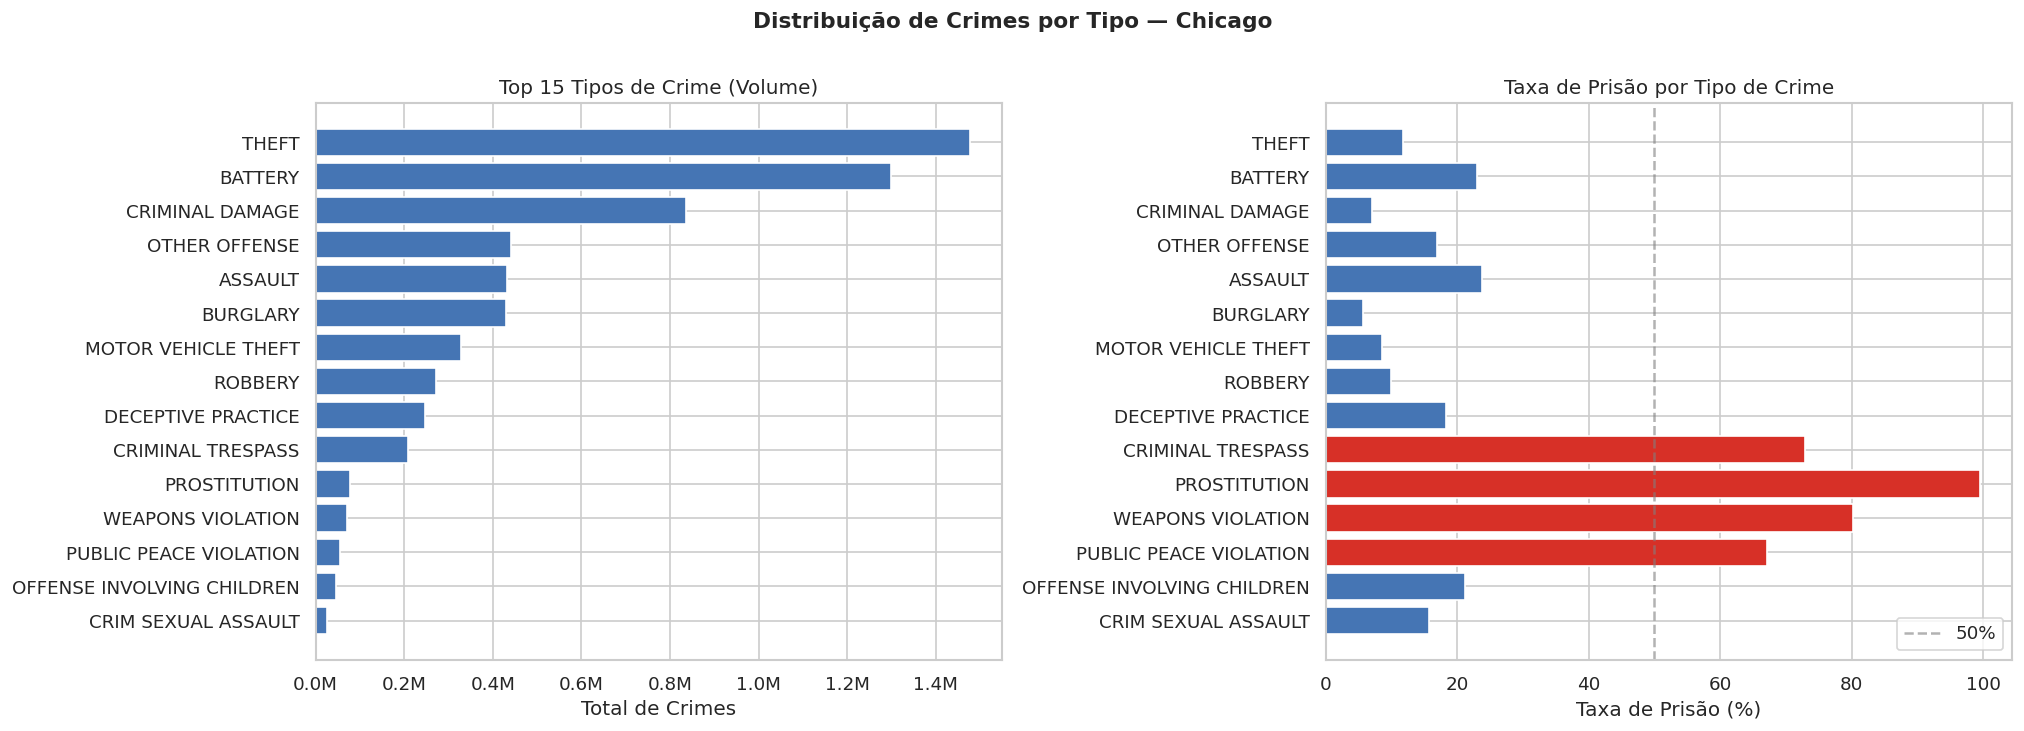

In [28]:
# Consulta SQL: top 15 tipos de crime por volume total e taxa de prisão
df_crimes_pd = spark.sql("""
    SELECT `Primary Type`,
           COUNT(*)                                        AS total_crimes,
           ROUND(SUM(Arrest_label) / COUNT(*) * 100, 2)  AS arrest_rate_pct
    FROM crimes
    GROUP BY `Primary Type`
    ORDER BY total_crimes DESC
    LIMIT 15
""").toPandas().iloc[::-1].reset_index(drop=True)  # inverte a ordem para barh crescente

# Dois gráficos lado a lado: volume à esquerda, taxa de prisão à direita
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Gráfico 1: volume de crimes por tipo (barras horizontais azuis)
axes[0].barh(df_crimes_pd["Primary Type"], df_crimes_pd["total_crimes"], color="#4575b4")
axes[0].set_xlabel("Total de Crimes")
axes[0].set_title("Top 15 Tipos de Crime (Volume)")
# Formata eixo x em milhões (ex: 1.2M em vez de 1200000)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Gráfico 2: taxa de prisão — vermelho para tipos com >50% de prisão, azul para os demais
colors = ["#d73027" if r > 50 else "#4575b4" for r in df_crimes_pd["arrest_rate_pct"]]
axes[1].barh(df_crimes_pd["Primary Type"], df_crimes_pd["arrest_rate_pct"], color=colors)
axes[1].set_xlabel("Taxa de Prisão (%)")
axes[1].set_title("Taxa de Prisão por Tipo de Crime")
# Linha de referência em 50% para facilitar leitura
axes[1].axvline(50, color="gray", linestyle="--", alpha=0.6, label="50%")
axes[1].legend(loc="lower right")

plt.suptitle("Distribuição de Crimes por Tipo — Chicago", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_01_crime_types.png", bbox_inches="tight")
plt.show()

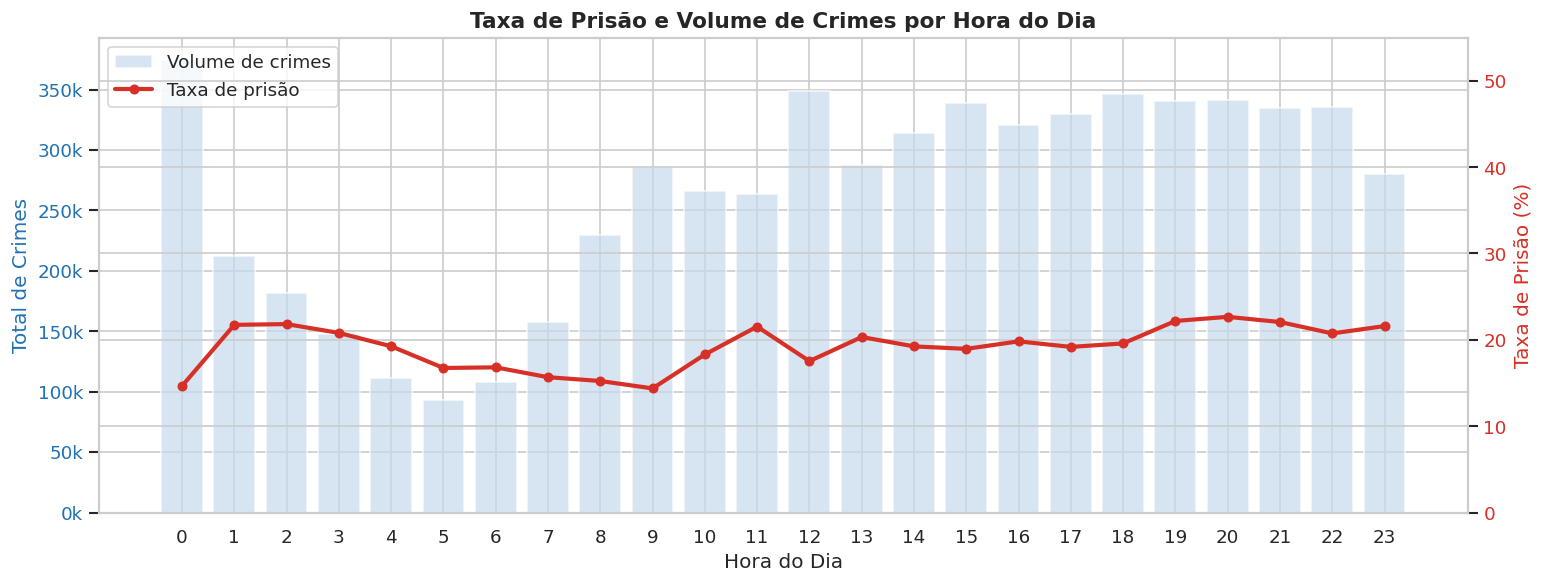

In [29]:
# Consulta SQL: volume de crimes e taxa de prisão para cada hora do dia (0–23)
df_hour_pd = spark.sql("""
    SELECT Hour,
           COUNT(*)                            AS total_crimes,
           ROUND(AVG(Arrest_label) * 100, 2)  AS arrest_rate_pct
    FROM crimes
    GROUP BY Hour
    ORDER BY Hour
""").toPandas()

# Gráfico com dois eixos Y: barras para volume (eixo esquerdo), linha para taxa (eixo direito)
fig, ax1 = plt.subplots(figsize=(13, 5))

color_bar = "#c6dbef"    # azul claro para as barras de volume
color_line = "#d73027"   # vermelho para a linha de taxa de prisão

# Eixo esquerdo: barras de volume de crimes por hora
ax1.bar(df_hour_pd["Hour"], df_hour_pd["total_crimes"], color=color_bar, alpha=0.7, label="Volume de crimes")
ax1.set_xlabel("Hora do Dia")
ax1.set_ylabel("Total de Crimes", color="#2171b5")
ax1.tick_params(axis="y", labelcolor="#2171b5")
ax1.set_xticks(range(0, 24))       # marca todas as 24 horas no eixo x
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))  # formata em k

# Eixo direito (twinx): linha de taxa de prisão sobreposta às barras
ax2 = ax1.twinx()
ax2.plot(df_hour_pd["Hour"], df_hour_pd["arrest_rate_pct"], color=color_line,
         linewidth=2.5, marker="o", markersize=5, label="Taxa de prisão")
ax2.set_ylabel("Taxa de Prisão (%)", color=color_line)
ax2.tick_params(axis="y", labelcolor=color_line)
ax2.set_ylim(0, 55)    # limita o eixo y da taxa para visualização clara

# Combina as legendas dos dois eixos numa só
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Taxa de Prisão e Volume de Crimes por Hora do Dia", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_02_arrest_by_hour.png", bbox_inches="tight")
plt.show()

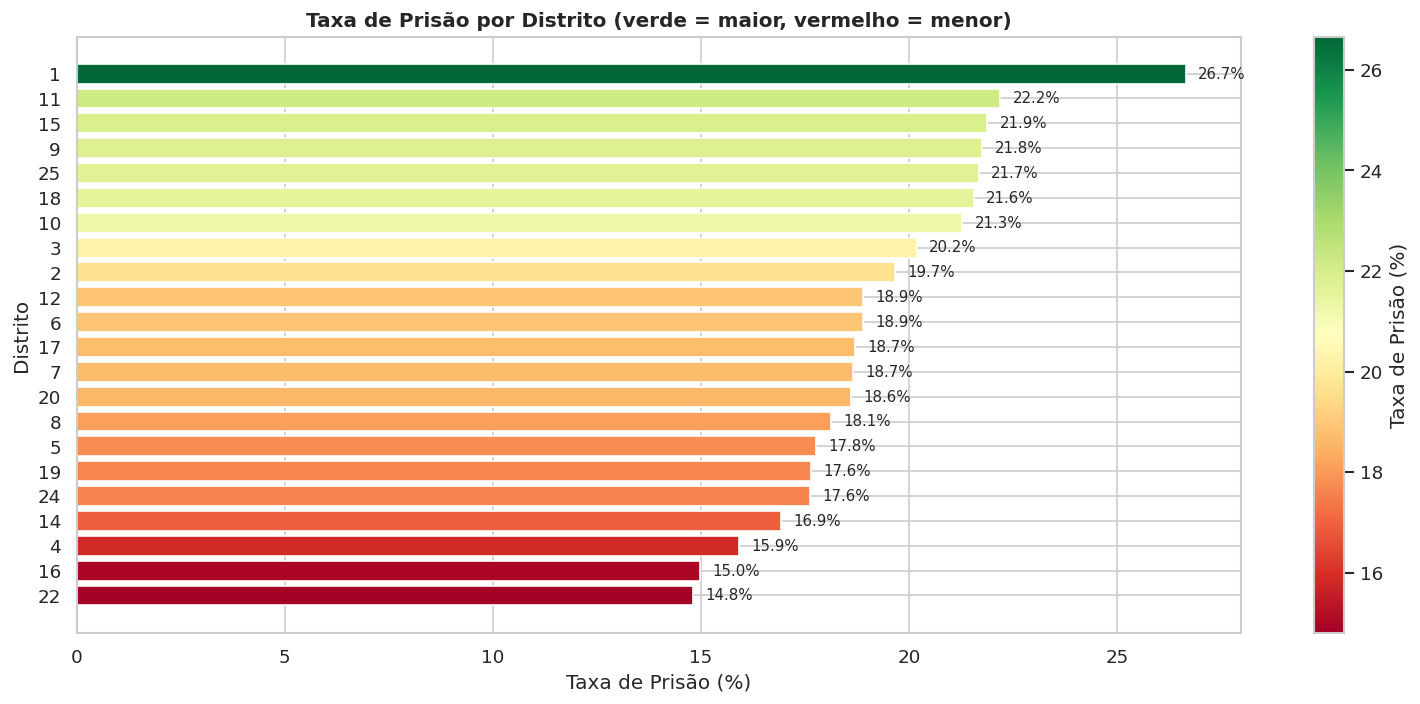

In [30]:
# Consulta SQL: taxa de prisão por distrito policial, ordenada crescente
df_dist_pd = spark.sql("""
    SELECT District,
           COUNT(*)                                        AS total_crimes,
           ROUND(SUM(Arrest_label) / COUNT(*) * 100, 2)  AS arrest_rate_pct
    FROM crimes
    WHERE District IS NOT NULL
    GROUP BY District
    HAVING COUNT(*) > 1000    -- filtra distritos com pouco volume (estatisticamente irrelevantes)
    ORDER BY District
""").toPandas().sort_values("arrest_rate_pct")  # ordena por taxa para visualização gradiente

fig, ax = plt.subplots(figsize=(13, 6))

# Normaliza os valores para mapear a escala de cores (verde=alta taxa, vermelho=baixa taxa)
norm = plt.Normalize(df_dist_pd["arrest_rate_pct"].min(), df_dist_pd["arrest_rate_pct"].max())
cmap = plt.cm.RdYlGn    # colormap: vermelho→amarelo→verde
colors = cmap(norm(df_dist_pd["arrest_rate_pct"]))  # cor de cada barra baseada no valor

# Barras horizontais com cor gradiente por taxa de prisão
bars = ax.barh(df_dist_pd["District"].astype(str), df_dist_pd["arrest_rate_pct"], color=colors)
ax.set_xlabel("Taxa de Prisão (%)")
ax.set_ylabel("Distrito")
ax.set_title("Taxa de Prisão por Distrito (verde = maior, vermelho = menor)", fontsize=12, fontweight="bold")

# Adiciona barra de cores à direita do gráfico como legenda visual
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Taxa de Prisão (%)")

# Anota o valor percentual ao lado de cada barra
for bar, val in zip(bars, df_dist_pd["arrest_rate_pct"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_03_arrest_by_district.png", bbox_inches="tight")
plt.show()

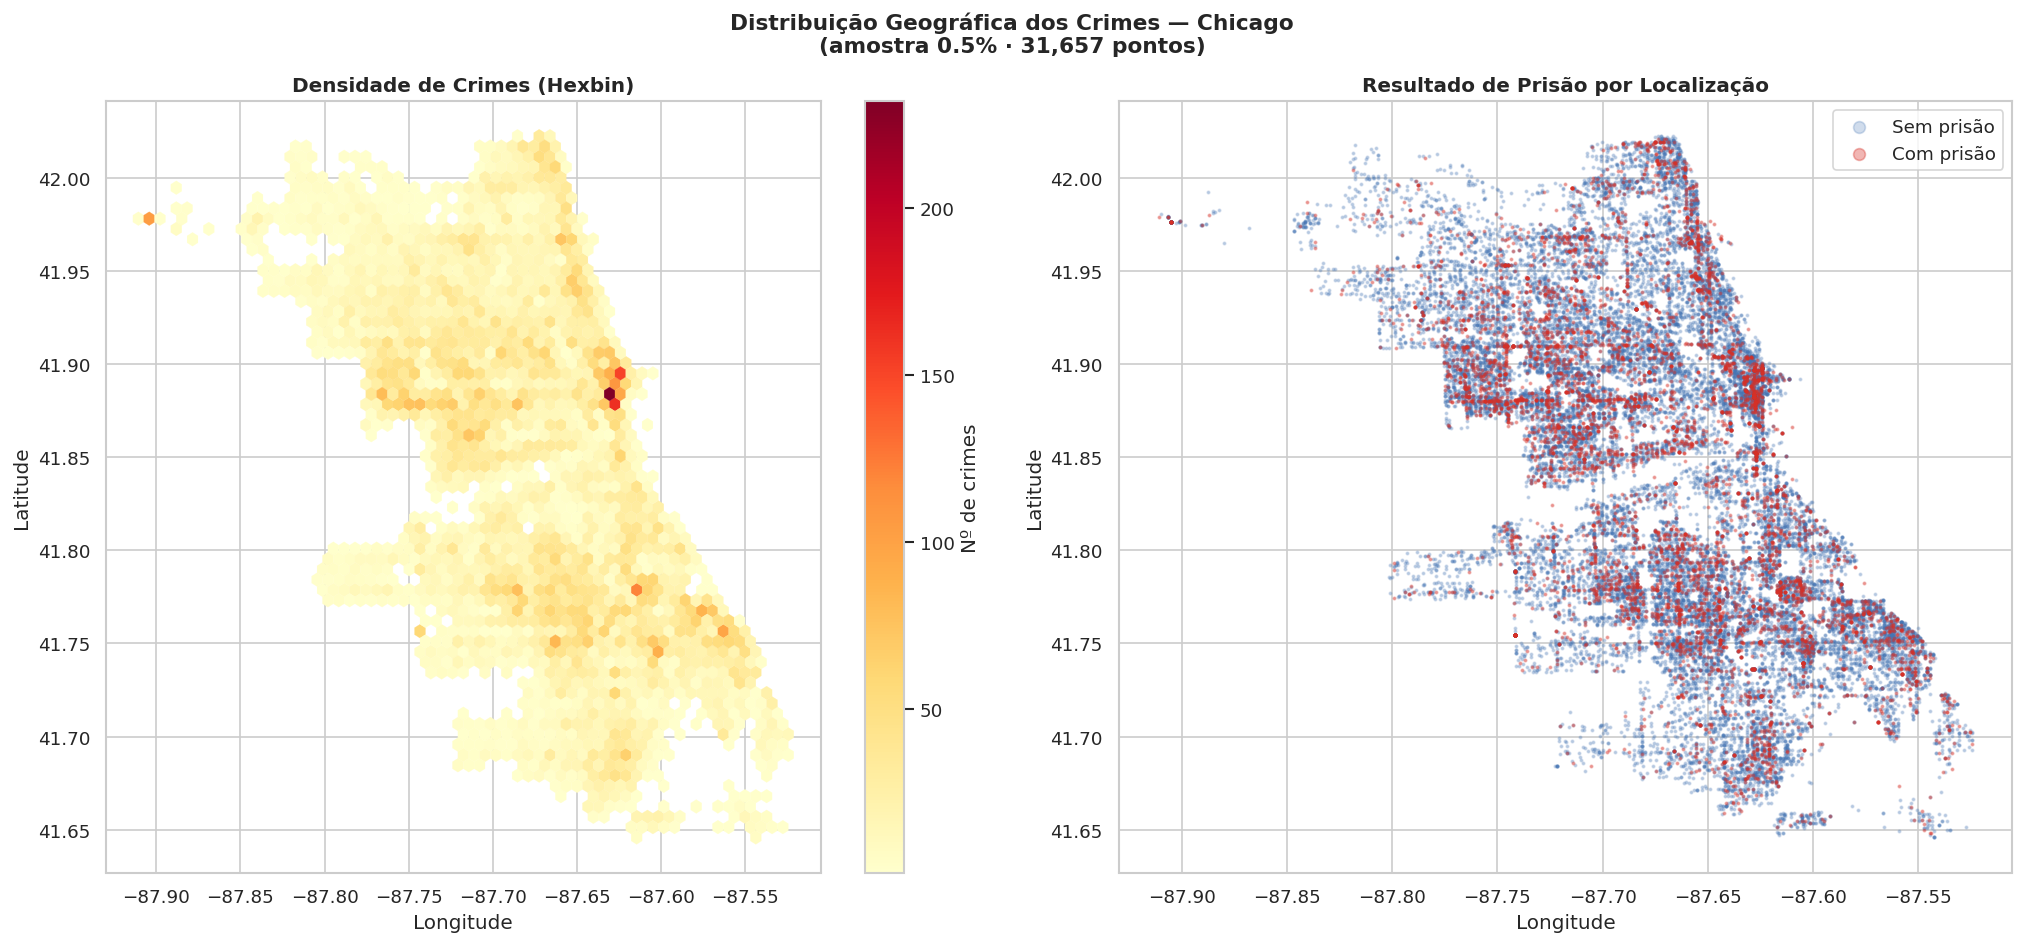

In [31]:
# Consulta SQL: amostra geoespacial filtrada para os limites de Chicago
# fraction=0.005 = 0.5% dos registros — suficiente para visualização sem sobrecarregar matplotlib
df_geo_pd = spark.sql("""
    SELECT Latitude, Longitude, Arrest_label
    FROM crimes
    WHERE Latitude  BETWEEN 41.6 AND 42.1     -- limites de latitude de Chicago
      AND Longitude BETWEEN -88.0 AND -87.5   -- limites de longitude de Chicago
""").sample(fraction=0.005, seed=42).toPandas()

# Separa os pontos por classe para colorir diferente no scatter
arrested     = df_geo_pd[df_geo_pd["Arrest_label"] == 1]
not_arrested = df_geo_pd[df_geo_pd["Arrest_label"] == 0]
n_pts = len(df_geo_pd)    # total de pontos na amostra

# Dois mapas lado a lado: densidade (hexbin) e resultado por ponto (scatter)
fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# Mapa 1: hexbin — agrega pontos em hexágonos coloridos por densidade
# gridsize=60: resolução da grade hexagonal (mais alto = hexágonos menores)
hb = axes[0].hexbin(
    df_geo_pd["Longitude"], df_geo_pd["Latitude"],
    gridsize=60, cmap="YlOrRd", mincnt=1, linewidths=0.15
)
plt.colorbar(hb, ax=axes[0], label="Nº de crimes")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Densidade de Crimes (Hexbin)", fontsize=12, fontweight="bold")

# Mapa 2: scatter com cor por classe — azul=sem prisão, vermelho=com prisão
# s=2, alpha baixo: pontos pequenos e semi-transparentes para ver sobreposição
axes[1].scatter(not_arrested["Longitude"], not_arrested["Latitude"],
                s=2, alpha=0.25, color="#4575b4", label="Sem prisão")
axes[1].scatter(arrested["Longitude"], arrested["Latitude"],
                s=2, alpha=0.35, color="#d73027", label="Com prisão")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Resultado de Prisão por Localização", fontsize=12, fontweight="bold")
axes[1].legend(markerscale=5, loc="upper right")  # markerscale=5: aumenta os marcadores na legenda

plt.suptitle(
    f"Distribuição Geográfica dos Crimes — Chicago\n(amostra 0.5% · {n_pts:,} pontos)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_04_geographic.png", bbox_inches="tight", dpi=150)
plt.show()

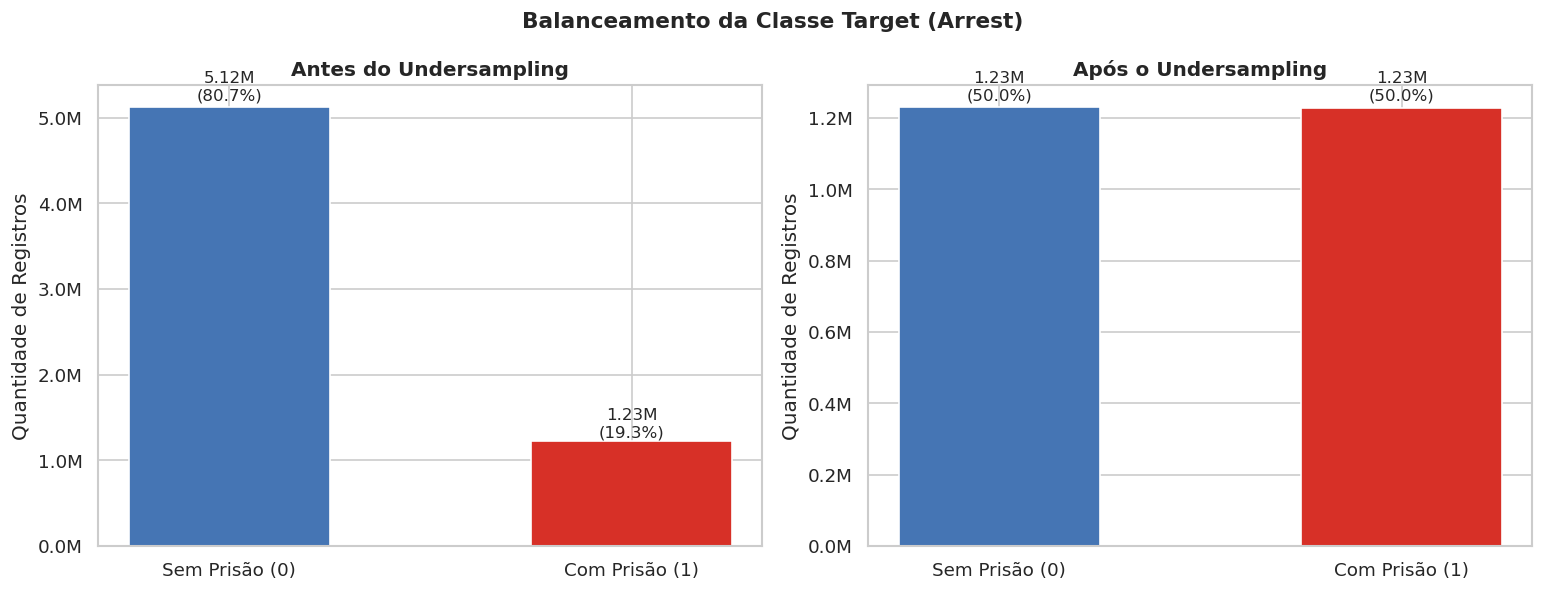

In [32]:
# Rótulos das barras para os dois gráficos (antes e depois do undersampling)
labels_before = ["Sem Prisão (0)", "Com Prisão (1)"]
labels_after  = ["Sem Prisão (0)", "Com Prisão (1)"]

# Tenta usar os valores calculados anteriormente; usa fallback hardcoded se não disponível
try:
    before_vals = [count_no_arrest, count_arrest]   # valores reais da célula 25
    # Conta as classes no dataset balanceado para confirmar o 50/50
    after_no    = df_balanced.filter(col(TARGET_COL) == 0).count()
    after_yes   = df_balanced.filter(col(TARGET_COL) == 1).count()
    after_vals  = [after_no, after_yes]
except NameError:
    # Fallback com valores do seventh-run caso as variáveis não estejam no escopo
    before_vals = [5_120_978, 1_228_274]
    after_vals  = [1_229_680, 1_228_274]

# Dois gráficos de barras verticais: antes (esquerda) e depois (direita) do undersampling
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#4575b4", "#d73027"]    # azul=sem prisão, vermelho=com prisão

# Itera nos dois pares de dados para criar gráficos idênticos na estrutura
for ax, vals, title in zip(axes,
                            [before_vals, after_vals],
                            ["Antes do Undersampling", "Após o Undersampling"]):
    bars = ax.bar(labels_before, vals, color=colors, width=0.5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Quantidade de Registros")
    # Formata eixo y em milhões (ex: 5.1M)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    total = sum(vals)
    # Anota valor absoluto e percentual acima de cada barra
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{v/1e6:.2f}M\n({v/total*100:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.suptitle("Balanceamento da Classe Target (Arrest)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_05_class_balance.png", bbox_inches="tight")
plt.show()

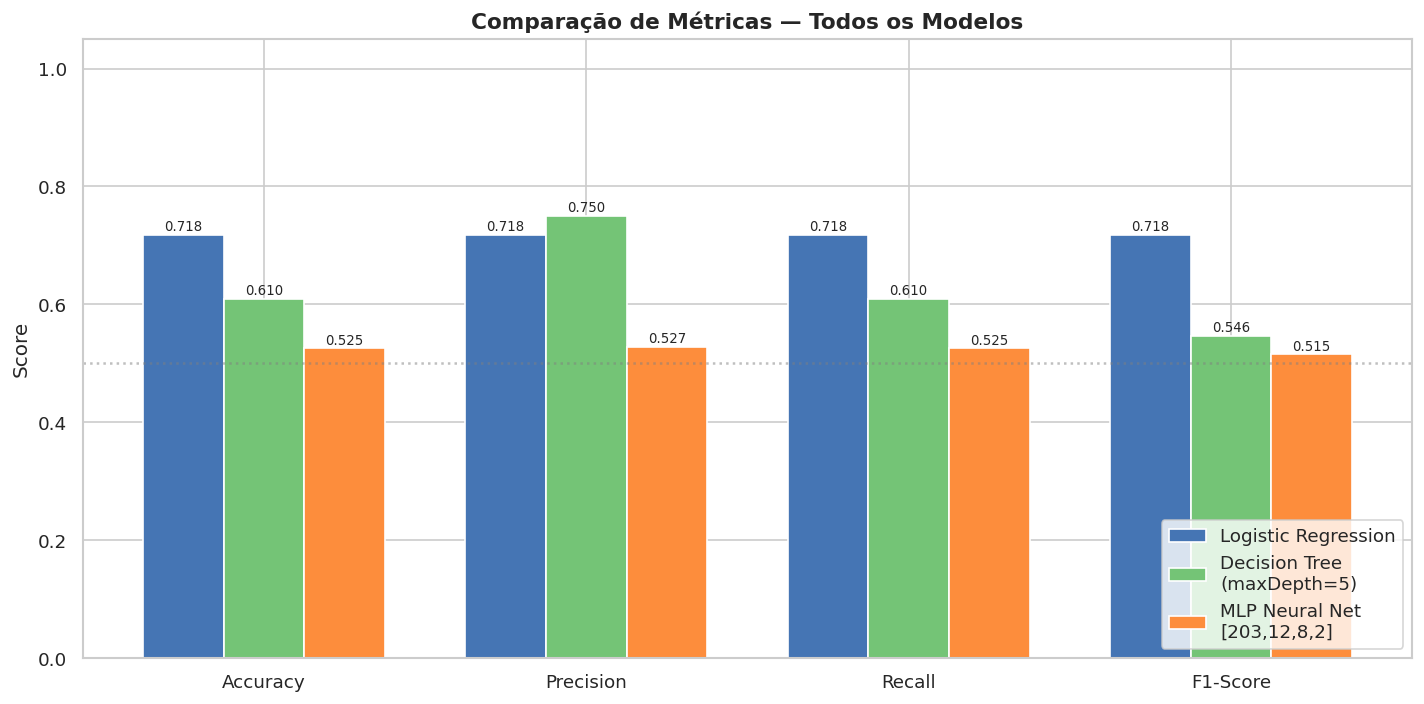

In [33]:
# Nomes dos modelos e métricas para o gráfico comparativo
model_names  = ["Logistic Regression", "Decision Tree\n(maxDepth=5)", "MLP Neural Net\n[203,12,8,2]"]
metric_names = ["accuracy", "weightedPrecision", "weightedRecall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]

# Função auxiliar para extrair valor de dicionário com fallback seguro
def _get(d, k):
    try: return d[k]
    except: return None

# Tenta usar métricas calculadas; usa valores do seventh-run como fallback
try:    row_lr = [metrics_lr[k]  for k in metric_names]
except: row_lr = [0.7181, 0.7182, 0.7181, 0.7181]

try:    row_dt = [metrics_dt[k]  for k in metric_names]
except: row_dt = [0.6100, 0.7501, 0.6100, 0.5462]

try:    row_mlp = [metrics_mlp[k] for k in metric_names]
except: row_mlp = [None, None, None, None]   # MLP pode não ter rodado

rows = [row_lr, row_dt, row_mlp]

# Posições e largura das barras agrupadas
x    = np.arange(len(metric_labels))
w    = 0.25    # largura de cada barra no grupo
fig, ax = plt.subplots(figsize=(12, 6))

# Uma cor por modelo para diferenciação visual
colors_models = ["#4575b4", "#74c476", "#fd8d3c"]
for i, (name, row, color) in enumerate(zip(model_names, rows, colors_models)):
    # None → 0 para barras de modelos sem resultado (ex: MLP incompleto)
    vals = [v if v is not None else 0 for v in row]
    bars = ax.bar(x + i * w, vals, w, label=name, color=color)
    # Anota o valor numérico acima de cada barra
    for bar, v in zip(bars, row):
        if v is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)
        else:
            # Barra vazia: anota 'N/A' na base
            ax.text(bar.get_x() + bar.get_width() / 2, 0.02,
                    "N/A", ha="center", va="bottom", fontsize=8, color="gray")

# Centraliza os rótulos do eixo x no meio do grupo de 3 barras
ax.set_xticks(x + w)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Comparação de Métricas — Todos os Modelos", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)  # linha de referência em 50% (chance aleatória)

plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_06_model_comparison.png", bbox_inches="tight")
plt.show()

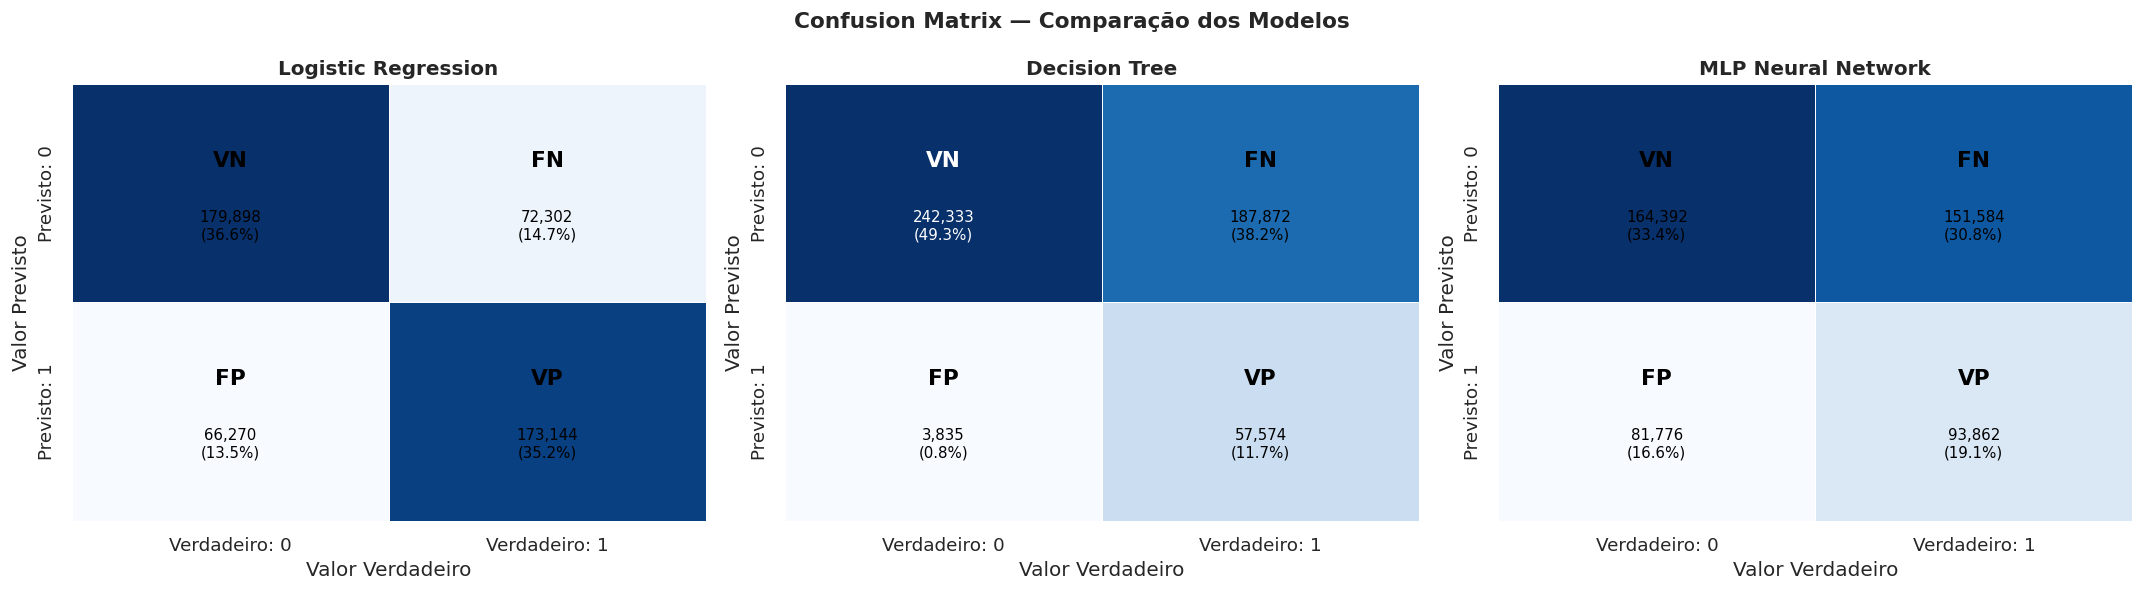

In [34]:
# Função que extrai a matriz de confusão 2x2 de um DataFrame de predições Spark
def compute_cm(predictions):
    # Agrupa por (valor real, valor previsto) e conta ocorrências
    cm_df = (predictions
             .groupBy(TARGET_COL, "prediction")
             .count()
             .toPandas())
    # Inicializa matriz 2x2 com zeros
    raw = np.zeros((2, 2), dtype=int)
    # Preenche: raw[real][pred] = contagem
    for _, row in cm_df.iterrows():
        real, pred = int(row[TARGET_COL]), int(row["prediction"])
        if 0 <= real <= 1 and 0 <= pred <= 1:
            raw[real][pred] = int(row["count"])
    return raw.T  # transposta: linhas=previsto, colunas=real (convenção padrão de exibição)

# Mapa de quadrantes da confusion matrix: (previsto, real) → sigla
QUAD = {(0, 0): "VN", (0, 1): "FN", (1, 0): "FP", (1, 1): "VP"}

# Coleta apenas os modelos cujas predições estão disponíveis no escopo
preds_avail = []
for name, pred_var in [("Logistic Regression", "pred_lr"),
                        ("Decision Tree",       "pred_dt"),
                        ("MLP Neural Network",  "pred_mlp")]:
    try:
        preds_avail.append((name, eval(pred_var)))
    except NameError:
        print(f"  {name}: predições não disponíveis")

# Um subplot por modelo disponível
n = max(len(preds_avail), 1)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
if n == 1:
    axes = [axes]    # garante que axes seja sempre uma lista

for ax, (name, preds) in zip(axes, preds_avail):
    cm = compute_cm(preds)
    total = cm.sum()
    cm_pct = cm / total * 100    # converte contagens para percentuais

    # Heatmap azul com anotações desativadas (serão adicionadas manualmente abaixo)
    sns.heatmap(cm_pct, annot=False, fmt="", cmap="Blues", ax=ax,
                xticklabels=["Verdadeiro: 0", "Verdadeiro: 1"],
                yticklabels=["Previsto: 0",   "Previsto: 1"],
                linewidths=0.5, cbar=False)

    # Adiciona manualmente sigla (VP/FP/FN/VN) e valor em cada célula
    for i in range(2):
        for j in range(2):
            label = QUAD[(i, j)]
            # Sigla em branco se fundo escuro (>40%), preto caso contrário
            ax.text(j + 0.5, i + 0.35,
                    label,
                    ha="center", va="center", fontsize=13, fontweight="bold",
                    color="white" if cm_pct[i, j] > 40 else "black")
            # Contagem absoluta e percentual na linha de baixo da célula
            ax.text(j + 0.5, i + 0.65,
                    f"{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)",
                    ha="center", va="center", fontsize=9,
                    color="white" if cm_pct[i, j] > 40 else "black")

    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Valor Verdadeiro")
    ax.set_ylabel("Valor Previsto")

plt.suptitle("Confusion Matrix — Comparação dos Modelos", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_07_confusion_matrices.png", bbox_inches="tight")
plt.show()

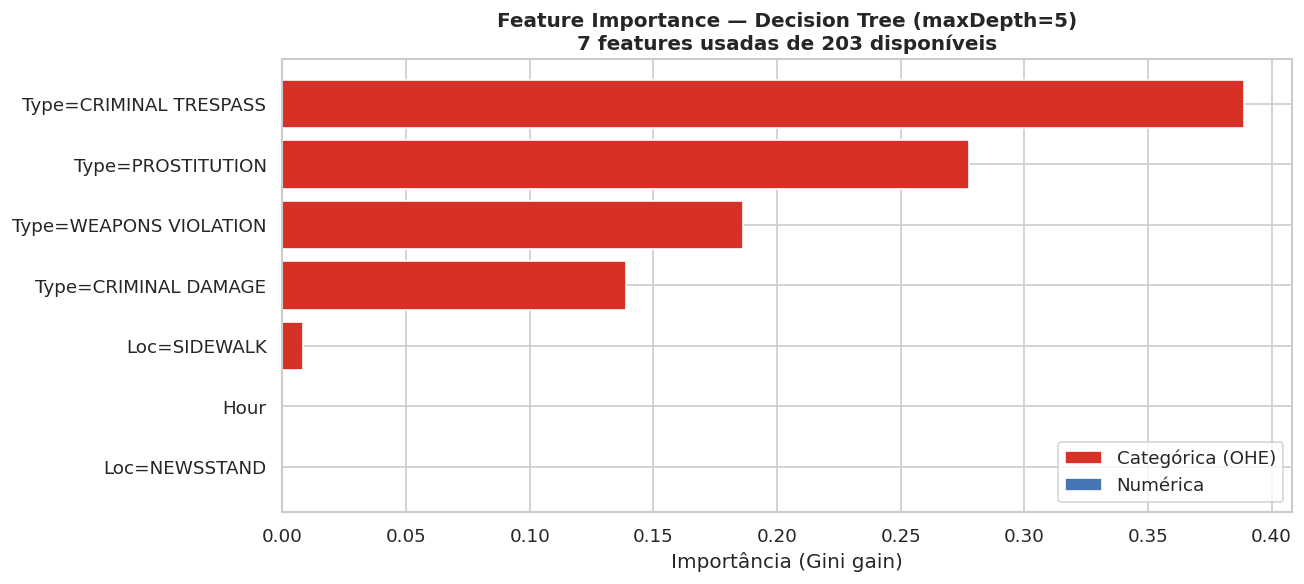

In [35]:
# Extrai e visualiza a importância de features da Decision Tree treinada
try:
    # Acessa os estágios do pipeline: 0=StringIndexer(Primary Type), 1=StringIndexer(Location),
    # 2=OneHotEncoder, 3=VectorAssembler, 4=DecisionTreeClassifier
    si_primary  = model_dt.stages[0]   # StringIndexer do tipo de crime
    si_location = model_dt.stages[1]   # StringIndexer da localização
    ohe         = model_dt.stages[2]   # OneHotEncoder (contém o tamanho de cada vocabulário)
    dt_clf      = model_dt.stages[4]   # o classificador Decision Tree em si

    # categorySizes[i] = número de categorias incluindo a dropada pelo OHE
    # -1 porque o OHE remove uma categoria para evitar multicolinearidade
    n_primary  = ohe.categorySizes[0] - 1
    n_location = ohe.categorySizes[1] - 1

    # Reconstrói os nomes de cada dimensão do vetor de features
    feature_names = (
        [f"Type={lbl}"      for lbl in si_primary.labels[:n_primary]]   +   # ex: Type=THEFT
        [f"Loc={lbl[:18]}"  for lbl in si_location.labels[:n_location]] +   # ex: Loc=STREET
        NUMERIC_COLS                                                         # Hour, District, etc.
    )

    # featureImportances: vetor esparso com a importância Gini de cada feature
    importances = dt_clf.featureImportances.toArray()
    # Filtra features com importância > 0, ordena descendente, pega top 20
    fi_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
               .query("importance > 0")
               .sort_values("importance", ascending=False)
               .head(20)
               .iloc[::-1])  # inverte para barh crescente

    n_features = len(fi_df)
    fig, ax = plt.subplots(figsize=(11, max(5, n_features * 0.45)))
    # Vermelho para features categóricas (OHE), azul para numéricas
    colors_fi = ["#d73027" if "Type=" in f or "Loc=" in f else "#4575b4"
                 for f in fi_df["feature"]]
    ax.barh(fi_df["feature"], fi_df["importance"], color=colors_fi)
    ax.set_xlabel("Importância (Gini gain)")
    ax.set_title(f"Feature Importance — Decision Tree (maxDepth=5)\n{n_features} features usadas de {len(feature_names)} disponíveis",
                 fontsize=12, fontweight="bold")

    # Legenda de cores para categórica vs numérica
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="#d73027", label="Categórica (OHE)"),
                       Patch(facecolor="#4575b4", label="Numérica")]
    ax.legend(handles=legend_elements, loc="lower right")

    plt.tight_layout()
    plt.savefig(SAVE_DIR + "chart_08_feature_importance.png", bbox_inches="tight")
    plt.show()

except NameError:
    print("model_dt não disponível — rode a seção 3.5 antes de executar esta célula.")

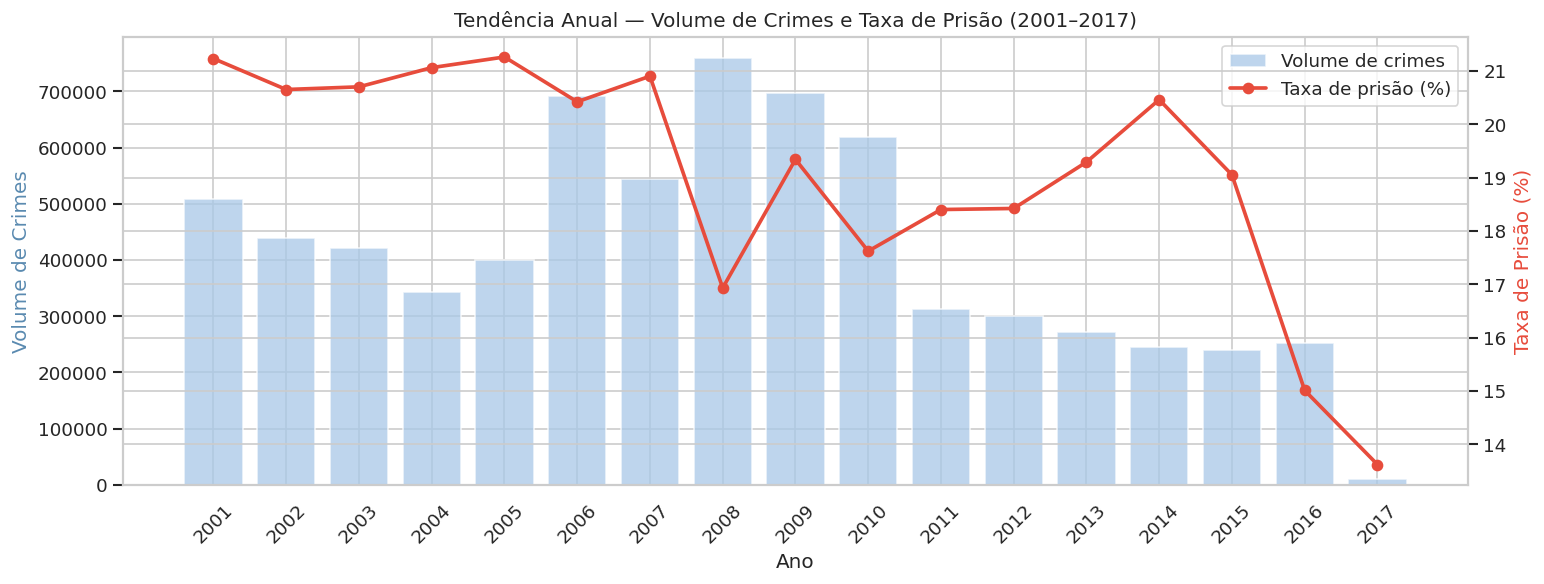

In [36]:
# Lê o Parquet bruto (crimes_raw) para ter todos os anos sem o balanceamento 50/50
# O balanceamento distorce a contagem anual pois faz undersampling da maioria
_df_raw = spark.read.parquet('/home/jovyan/work/data_parquet/crimes_raw')
# Remove NARCOTICS também aqui para consistência com o dataset de treino
_df_raw = _df_raw.filter(col('Primary Type') != 'NARCOTICS')
# Cria coluna inteira de Arrest para cálculo de média
_df_raw = _df_raw.withColumn('_arrest_int', (col('Arrest') == 'True').cast(IntegerType()))
# Converte Year para inteiro (pode ser string nos CSVs)
_df_raw = _df_raw.withColumn('Year_int', col('Year').cast(IntegerType()))

# Importa funções com aliases para evitar conflito com funções já importadas
from pyspark.sql.functions import avg as _avg, count as _count, round as _rnd
# Agrupa por ano: conta crimes e calcula taxa de prisão média
df_year_pd = (
    _df_raw.filter((col('Year_int') >= 2001) & (col('Year_int') <= 2017))
           .groupBy('Year_int')
           .agg(
               _count('*').alias('total_crimes'),
               _rnd(_avg('_arrest_int') * 100, 2).alias('arrest_rate_pct')
           )
           .orderBy('Year_int')
           .toPandas()
)

# Gráfico duplo-eixo: barras (volume) + linha (taxa) por ano
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# Barras azuis para volume anual de crimes
ax1.bar(df_year_pd["Year_int"], df_year_pd["total_crimes"],
        color="#a8c8e8", alpha=0.75, label="Volume de crimes")
# Linha vermelha com marcadores para taxa de prisão anual
ax2.plot(df_year_pd["Year_int"], df_year_pd["arrest_rate_pct"],
         color="#e74c3c", marker="o", linewidth=2.2, label="Taxa de prisão (%)")

ax1.set_xlabel("Ano")
ax1.set_ylabel("Volume de Crimes", color="#5a8ab0")
ax2.set_ylabel("Taxa de Prisão (%)", color="#e74c3c")
ax1.set_title("Tendência Anual — Volume de Crimes e Taxa de Prisão (2001–2017)")
ax1.set_xticks(df_year_pd["Year_int"])
ax1.set_xticklabels(df_year_pd["Year_int"], rotation=45)

# Combina legendas dos dois eixos
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

plt.tight_layout()
plt.savefig(SAVE_DIR + "annual_trend.png", dpi=120, bbox_inches="tight")
plt.show()

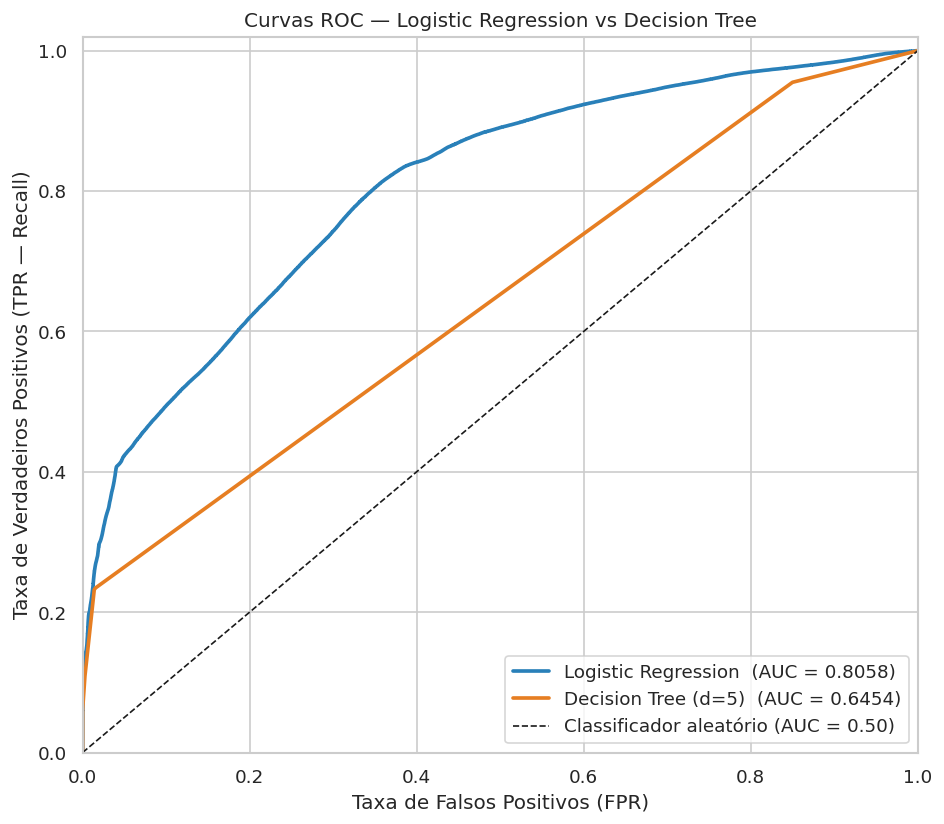

In [41]:
# Caminho base dos arquivos Parquet de predições
_sd = "/home/jovyan/work/data_parquet/"
# Verifica se o SparkContext está ativo; recarrega tudo se necessário
try:
    spark.sparkContext.parallelize([1], 1).count()  # teste mínimo de conectividade
except Exception:
    # SparkContext morto — recria a sessão
    from pyspark.sql import SparkSession
    spark = SparkSession.builder \
        .appName("CrimesChicago_BigData") \
        .master("spark://spark-master:7077") \
        .config("spark.driver.host", "jupyter") \
        .config("spark.driver.bindAddress", "0.0.0.0") \
        .config("spark.driver.memory", "2g") \
        .config("spark.executor.memory", "2g") \
        .config("spark.sql.shuffle.partitions", "50") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("WARN")
    # Recarrega as predições salvas em Parquet pelas células 37 e 39
    pred_lr = spark.read.parquet(_sd + "pred_lr_roc")
    pred_dt = spark.read.parquet(_sd + "pred_dt_roc")
    print("Sessão reiniciada. pred_lr e pred_dt recarregados do parquet.")

# UDF que extrai a probabilidade da classe positiva (índice 1) do vetor de probabilidades
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType
from sklearn.metrics import roc_curve, auc as sklearn_auc

_prob_udf = udf(lambda v: float(v[1]), DoubleType())

# Função que calcula pontos da curva ROC e AUC para um DataFrame de predições
def get_roc_auc(predictions, label_col=TARGET_COL):
    # Converte para pandas para usar sklearn (BinaryClassificationMetrics não tem .roc nesta versão)
    pdf = predictions.select(
        _prob_udf("probability").alias("prob"),
        col(label_col).cast("double").alias("label")
    ).toPandas()
    # roc_curve retorna (fpr, tpr, thresholds)
    fpr, tpr, _ = roc_curve(pdf["label"], pdf["prob"])
    # sklearn_auc calcula a área sob a curva via regra do trapézio
    return list(zip(fpr, tpr)), sklearn_auc(fpr, tpr)

# Cria figura com os dois modelos sobrepostos
fig, ax = plt.subplots(figsize=(8, 7))

# Plota curva ROC de cada modelo com cor e rótulo distintos
for pred_obj, name, color in [
    (pred_lr, "Logistic Regression", "#2980b9"),
    (pred_dt, "Decision Tree (d=5)", "#e67e22"),
]:
    try:
        roc_pts, auc_val = get_roc_auc(pred_obj)
        fpr = [p[0] for p in roc_pts]
        tpr = [p[1] for p in roc_pts]
        ax.plot(fpr, tpr, color=color, linewidth=2.2, label=f"{name}  (AUC = {auc_val:.4f})")
    except Exception as e:
        print(f"{name}: {e}")

# Linha diagonal tracejada = classificador aleatório (AUC=0.5) — referência mínima
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Classificador aleatório (AUC = 0.50)")
ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR — Recall)")
ax.set_title("Curvas ROC — Logistic Regression vs Decision Tree")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(SAVE_DIR + "roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()

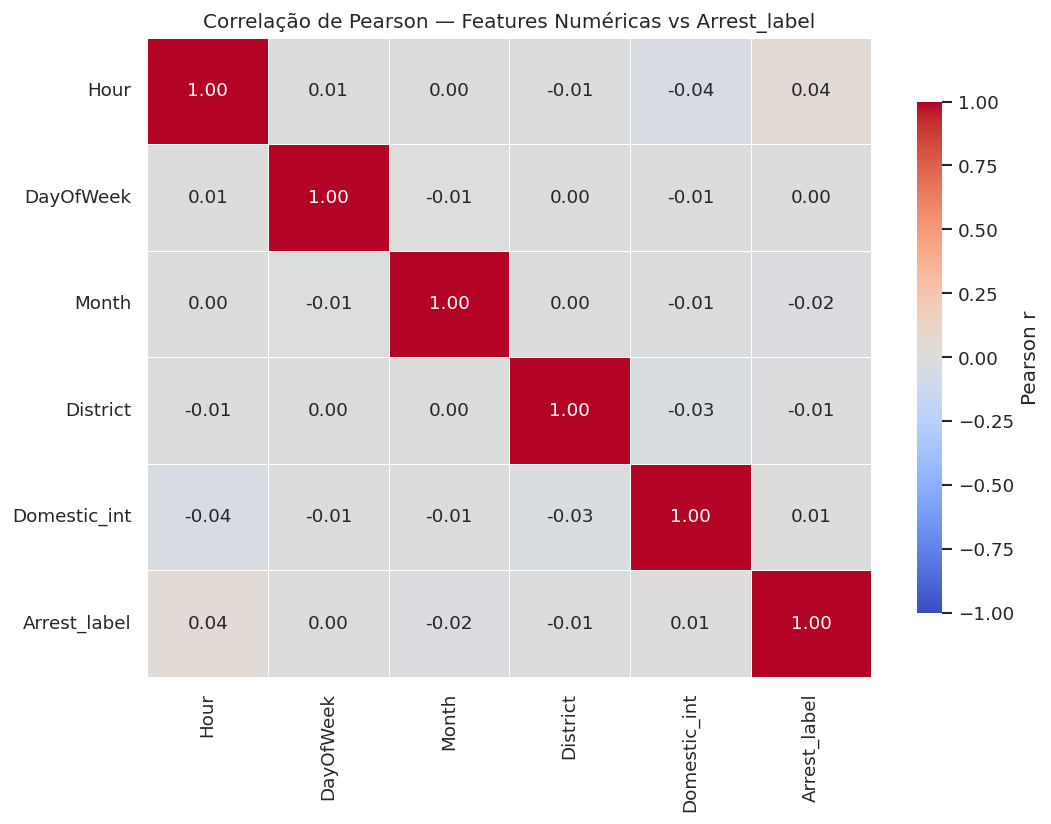

In [38]:
# Verifica conectividade do Spark; reinicia e recarrega se necessário
try:
    spark.sparkContext.parallelize([1], 1).count()
except Exception:
    from pyspark.sql import SparkSession
    spark = SparkSession.builder \
        .appName("CrimesChicago_BigData") \
        .master("spark://spark-master:7077") \
        .config("spark.driver.host", "jupyter") \
        .config("spark.driver.bindAddress", "0.0.0.0") \
        .config("spark.driver.memory", "2g") \
        .config("spark.executor.memory", "2g") \
        .config("spark.sql.shuffle.partitions", "50") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("WARN")
    df_balanced = spark.read.parquet("/home/jovyan/work/data_parquet/crimes_balanced")
    print("Sessão reiniciada. df_balanced recarregado.")

# Importa Correlation do MLlib e VectorAssembler com alias para evitar conflito
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler as _VA

# Colunas numéricas para incluir na matriz de correlação
corr_cols = ["Hour", "DayOfWeek", "Month", "District", "Domestic_int", "Arrest_label"]
# Monta um vetor com todas essas colunas para o Correlation.corr()
_asm = _VA(inputCols=corr_cols, outputCol="_corr_vec", handleInvalid="skip")
df_corr_input = _asm.transform(df_balanced.select(corr_cols))
# Calcula a matriz de correlação de Pearson distribuída pelo Spark
corr_matrix = Correlation.corr(df_corr_input, "_corr_vec").collect()[0][0].toArray()
# Converte para DataFrame pandas para visualização com seaborn
corr_df = pd.DataFrame(corr_matrix, index=corr_cols, columns=corr_cols)

# Heatmap de correlação: azul=correlação negativa, vermelho=positiva, branco=zero
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)
ax.set_title("Correlação de Pearson — Features Numéricas vs Arrest_label")
plt.tight_layout()
plt.savefig(SAVE_DIR + "correlation_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [39]:
# Encerra a SparkSession e libera recursos no cluster (workers e driver)
# Sempre encerrar explicitamente para evitar vazamento de conexões
spark.stop()
print("SparkSession encerrada.")

SparkSession encerrada.
